<a href="https://colab.research.google.com/github/DanielSammaritani/Simple_Trading_Strategy/blob/main/Moving%20Average%20Crossover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The strategy is a momentum trend strategy, infact when the "small moving average" (20 days) surpass the "long moving average" (60 DAYS), the strategy buys the assets so following trend.
It Does the opposite when the LMA surpass the SMA.

Download the libraries and get the data from yahoofinance

In [62]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
import yfinance as yf
import pandas as pd
from google.colab import data_table

I downloaded the data of 11 ETFs covering the vat majority of sectors, so we can observe in which sector the strategy performs better

In [63]:
import yfinance as yf


tickers = [
    "IXN",
    "IXJ",
    "IXG",
    "IXC",
    "RXI",
    "KXI",
    "EXI",
    "MXI",
    "IXP",
    "JXI",
    "REET"
]

# Download dei prezzi di chiusura

data = yf.download(tickers ,start="2020-01-01")
print(data)

/tmp/ipykernel_795/2764974521.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers ,start="2020-01-01")
[*********************100%***********************]  11 of 11 completed


Price            Close                                                 \
Ticker             EXI        IXC         IXG         IXJ         IXN   
Date                                                                    
2020-01-02   89.387093  23.921715   58.735291   63.062168   34.173946   
2020-01-03   88.781181  23.952505   58.161186   62.595844   33.763866   
2020-01-06   88.772156  24.275774   58.034554   62.888439   33.864388   
2020-01-07   88.690758  24.152620   57.781281   62.742138   33.864388   
2020-01-08   89.043457  23.860144   58.000767   63.117020   34.225006   
...                ...        ...         ...         ...         ...   
2026-08-27  201.110001  56.980000  133.979996  105.169998  142.660004   
2026-08-28  199.669998  57.099998  134.550003  104.769997  140.600006   
2026-08-31  197.800003  58.180000  134.210007  104.239998  141.130005   
2026-09-01  194.690002  59.180000  133.100006  104.769997  139.360001   
2026-09-02  194.389999  59.200001  134.740005  105.

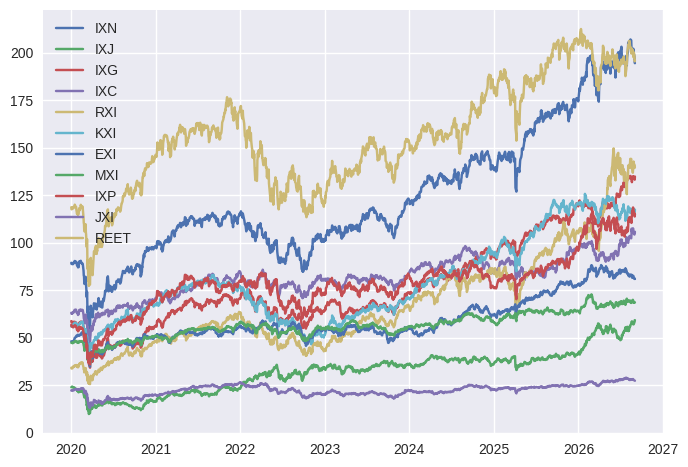

In [80]:
plt.plot(data["Close"])
plt.legend(tickers)
data.dropna(inplace=True)
plt.show()

The moving averages are 20 and 60 days

In [65]:
SMA= data["Close"].rolling(20).mean()
LMA = data["Close"].rolling(60).mean()
print(data)

Price            Close                                                 \
Ticker             EXI        IXC         IXG         IXJ         IXN   
Date                                                                    
2020-01-02   89.387093  23.921715   58.735291   63.062168   34.173946   
2020-01-03   88.781181  23.952505   58.161186   62.595844   33.763866   
2020-01-06   88.772156  24.275774   58.034554   62.888439   33.864388   
2020-01-07   88.690758  24.152620   57.781281   62.742138   33.864388   
2020-01-08   89.043457  23.860144   58.000767   63.117020   34.225006   
...                ...        ...         ...         ...         ...   
2026-08-27  201.110001  56.980000  133.979996  105.169998  142.660004   
2026-08-28  199.669998  57.099998  134.550003  104.769997  140.600006   
2026-08-31  197.800003  58.180000  134.210007  104.239998  141.130005   
2026-09-01  194.690002  59.180000  133.100006  104.769997  139.360001   
2026-09-02  194.389999  59.200001  134.740005  105.

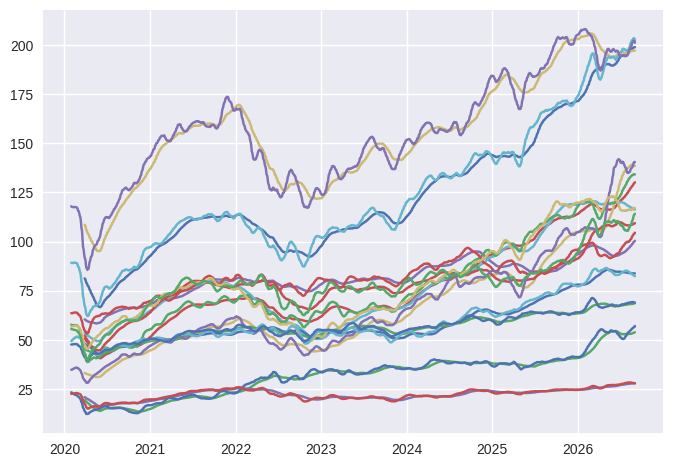

In [86]:
plt.plot(LMA)
plt.plot(SMA)
plt.show()

We define the strategy with the where functions from numpy


In [67]:


strategia = pd.DataFrame(np.where(SMA>LMA,+1,-1), index = SMA.index, columns = SMA.columns)
data.dropna(inplace=True)
print(strategia)
print(data)

Ticker      EXI  IXC  IXG  IXJ  IXN  IXP  JXI  KXI  MXI  REET  RXI
Date                                                              
2020-01-02   -1   -1   -1   -1   -1   -1   -1   -1   -1    -1   -1
2020-01-03   -1   -1   -1   -1   -1   -1   -1   -1   -1    -1   -1
2020-01-06   -1   -1   -1   -1   -1   -1   -1   -1   -1    -1   -1
2020-01-07   -1   -1   -1   -1   -1   -1   -1   -1   -1    -1   -1
2020-01-08   -1   -1   -1   -1   -1   -1   -1   -1   -1    -1   -1
...         ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...
2026-08-27    1    1    1    1    1    1   -1    1    1     1    1
2026-08-28    1    1    1    1    1    1   -1    1    1     1    1
2026-08-31    1    1    1    1    1    1   -1    1    1     1    1
2026-09-01    1    1    1    1    1    1   -1    1    1     1    1
2026-09-02    1    1    1    1    1    1   -1    1    1    -1    1

[1676 rows x 11 columns]
Price            Close                                                 \
Ticker             EXI        

Transoform the close price into logaritmic values, so we can add directly the % change onto the base of 100

In [83]:
Price = np.log(data["Close"]/data["Close"].shift(1))
strat = Price*strategia.shift(1)
print(strat)
print(Price)


Ticker           EXI       IXC       IXG       IXJ       IXN  ...       JXI  \
Date                                                          ...             
2020-01-02       NaN       NaN       NaN       NaN       NaN  ...       NaN   
2020-01-03  0.006802 -0.001286  0.009823  0.007422  0.012072  ...  0.001202   
2020-01-06  0.000102 -0.013406  0.002180 -0.004663 -0.002973  ... -0.000172   
2020-01-07  0.000917  0.005086  0.004374  0.002329 -0.000000  ...  0.004476   
2020-01-08 -0.003969  0.012183 -0.003791 -0.005957 -0.010593  ... -0.000000   
...              ...       ...       ...       ...       ...  ...       ...   
2026-08-27 -0.004465 -0.001754 -0.006324 -0.010781  0.027862  ...  0.006931   
2026-08-28 -0.007186  0.002104  0.004245 -0.003811 -0.014545  ...  0.005138   
2026-08-31 -0.009410  0.018738 -0.002530 -0.005072  0.003762  ...  0.007756   
2026-09-01 -0.015848  0.017042 -0.008305  0.005072 -0.012621  ... -0.002345   
2026-09-02 -0.001542  0.000338  0.012246  0.008837  

We calculate the classic metrics

In [69]:
#METRICS
#-Cumulative Returns
Cum_return_strat = np.exp(strat.sum())-1
print(Cum_return_strat)
Cum_return_bh = np.exp(Price.sum())-1
print(Cum_return_bh)
#-Sharpe Ratio strat
annualized_growth_strat = np.exp(strat.mean()*252)-1
annualized_risk_free_rate =np.exp(0.04244)-1
annualized_volatility = strat.std() * np.sqrt(252)
Sharpe_strat = (annualized_growth_strat-annualized_risk_free_rate)/annualized_volatility
#-Sharpe Ratio LDO
annualized_growth_bh = np.exp((Price.mean())*252)-1
annualized_volatility_bh = Price.std() * np.sqrt(252)
Sharpe_bh = (annualized_growth_bh-annualized_risk_free_rate)/annualized_volatility_bh
print(Sharpe_strat)
print(Sharpe_bh)
#MAX drawdown strategy
cum_log_ret = strat.cumsum()
val = np.exp(cum_log_ret)
d_max = val.cummax()
d = (d_max-val)/d_max
print(d.max())
#max drawdown bh
cum_log_ret_bh= Price.cumsum()
val_bh = np.exp(cum_log_ret_bh)
d_max_bh = val_bh.cummax()
d_bh = (d_max_bh - val_bh)/d_max_bh
print(d_bh.max())

Ticker
EXI     0.362169
IXC    -0.088964
IXG     0.095329
IXJ    -0.384163
IXN     0.209457
IXP     1.640771
JXI    -0.306008
KXI    -0.272420
MXI    -0.066037
REET   -0.047943
RXI     0.393168
dtype: float64
Ticker
EXI     1.174699
IXC     1.474739
IXG     1.294021
IXJ     0.676124
IXN     3.088787
IXP     1.094798
JXI     0.682753
KXI     0.449476
MXI     1.023126
REET    0.232330
RXI     0.650761
dtype: float64
Ticker
EXI     0.020527
IXC    -0.185002
IXG    -0.131627
IXJ    -0.659084
IXN    -0.051210
IXP     0.545762
JXI    -0.498760
KXI    -0.584610
MXI    -0.234055
REET   -0.231740
RXI     0.033987
dtype: float64
Ticker
EXI     0.390128
IXC     0.331871
IXG     0.399670
IXJ     0.217110
IXN     0.689198
IXP     0.355801
JXI     0.196238
KXI     0.091403
MXI     0.299283
REET   -0.052204
RXI     0.152458
dtype: float64
Ticker
EXI     0.395393
IXC     0.732807
IXG     0.487250
IXJ     0.634564
IXN     0.399279
IXP     0.188843
JXI     0.645677
KXI     0.468587
MXI     0.587714
REET

In [74]:
dashboard = pd.DataFrame(
     {"strat-result" : Cum_return_strat,
        "b-h result" : Cum_return_bh,
        "strat-sharpe" : Sharpe_strat,
        "b-h sharpe" : Sharpe_bh,
        "strat max-drawdown" : d.max(),
        "b-h max-drawdown" : d_bh.max()
    }

)

print(dashboard)


        strat-result  b-h result  strat-sharpe  b-h sharpe  \
Ticker                                                       
EXI         0.362169    1.174699      0.020527    0.390128   
IXC        -0.088964    1.474739     -0.185002    0.331871   
IXG         0.095329    1.294021     -0.131627    0.399670   
IXJ        -0.384163    0.676124     -0.659084    0.217110   
IXN         0.209457    3.088787     -0.051210    0.689198   
IXP         1.640771    1.094798      0.545762    0.355801   
JXI        -0.306008    0.682753     -0.498760    0.196238   
KXI        -0.272420    0.449476     -0.584610    0.091403   
MXI        -0.066037    1.023126     -0.234055    0.299283   
REET       -0.047943    0.232330     -0.231740   -0.052204   
RXI         0.393168    0.650761      0.033987    0.152458   

        strat max-drawdown  b-h max-drawdown  
Ticker                                        
EXI               0.395393          0.395600  
IXC               0.732807          0.595434  
IXG  

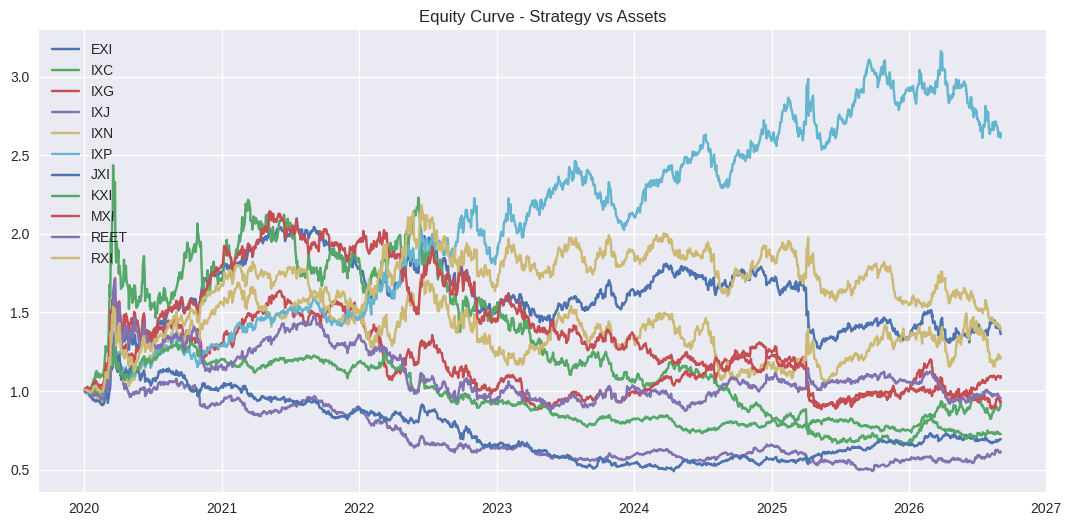

In [104]:
plt.figure(figsize=(13,6))
plt.plot(val)
plt.title("Equity Curve - Strategy vs Assets")
plt.legend(val.columns)
plt.show()

Conclusion: As shown in the dashboard, buy-and-hold outperformed the Moving Average Crossover (20/60) strategy in 10 out of 11 sectors between 2020 and 2026, with IXP (communication services) being the only exception. This suggests that in a strongly trending bull market, a simple crossover strategy tends to generate false or delayed signals, entering and exiting positions after part of the move has already happened — causing it to lag behind a passive approach